### Credit Card Fraud Detection — Phase 3: Unsupervised Anomaly Detection
### ULB Credit Card Fraud Dataset
 
Steps:
  1. Load & preprocess (mirrors Phase 2)
  2. Isolation Forest
  3. Local Outlier Factor
  4. Autoencoder (PyTorch) — train on legit only, score by reconstruction error
  5. Compare all three unsupervised models

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from sklearn.ensemble import IsolationForest
from sklearn.neighbors import LocalOutlierFactor
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (average_precision_score, roc_auc_score,
                             precision_score, recall_score, f1_score,
                             confusion_matrix, ConfusionMatrixDisplay,
                             precision_recall_curve)
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
import warnings
warnings.filterwarnings("ignore")
 
plt.rcParams.update({"figure.facecolor": "white", "axes.spines.top": False,
                     "axes.spines.right": False, "axes.grid": True,
                     "grid.color": "#e5e5e5"})
 
SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

### LOAD & PREPROCESS

In [2]:
print("Loading data...")
df = pd.read_csv("creditcard.csv")
 
df["LogAmount"] = np.log1p(df["Amount"])
df = df.drop(columns=["Time", "Amount"])
 
X = df.drop(columns=["Class"]).values
y = df["Class"].values
 
# Scale LogAmount (last column); V1-V28 already scaled
scaler = StandardScaler()
X[:, -1] = scaler.fit_transform(X[:, -1].reshape(-1, 1)).ravel()
 
# ── Split — same seed as Phase 2 for consistent test set ────────────────
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=SEED
)
 
# ── Unsupervised: train on LEGIT transactions only ───────────────────────
X_train_legit = X_train[y_train == 0]
 
print(f"Total train      : {len(X_train):,}")
print(f"Legit train only : {len(X_train_legit):,}  ← unsupervised models train here")
print(f"Test set         : {len(X_test):,}  (fraud={y_test.sum()})")
 
results      = {}
anomaly_probs = {}

Loading data...
Total train      : 227,845
Legit train only : 227,451  ← unsupervised models train here
Test set         : 56,962  (fraud=98)


### ISOLATION FOREST

In [3]:
#    Isolates anomalies by randomly partitioning feature space.
#    Anomalies require fewer splits to isolate → shorter path length.
#    contamination = expected fraction of outliers in the dataset.
# ════════════════════════════════════════════════════════════════════════════
 
print("\n── Isolation Forest ──────────────────────────────────────────")
 
iso = IsolationForest(
    n_estimators=200,
    contamination=0.002,   # slightly above the 0.17% true fraud rate
    max_samples="auto",
    random_state=SEED,
    n_jobs=-1,
)
iso.fit(X_train_legit)
 
# decision_function returns anomaly score: lower = more anomalous
# Negate so higher score = more likely fraud (consistent with predict_proba)
iso_scores = -iso.decision_function(X_test)
# Normalise to [0,1] for interpretability
iso_scores = (iso_scores - iso_scores.min()) / (iso_scores.max() - iso_scores.min())
 
iso_pred = (iso.predict(X_test) == -1).astype(int)  # -1 = anomaly
 
pr_auc = average_precision_score(y_test, iso_scores)
recall = recall_score(y_test, iso_pred)
prec   = precision_score(y_test, iso_pred, zero_division=0)
f1     = f1_score(y_test, iso_pred, zero_division=0)
fn     = confusion_matrix(y_test, iso_pred)[1, 0]
 
results["Isolation Forest"] = {
    "PR-AUC": round(pr_auc, 4), "Recall": round(recall, 4),
    "Precision": round(prec, 4), "F1": round(f1, 4), "FN": fn,
}
anomaly_probs["Isolation Forest"] = iso_scores
 
print(f"  PR-AUC={pr_auc:.4f}  Recall={recall:.4f}  "
      f"Precision={prec:.4f}  F1={f1:.4f}  FN={fn}")


── Isolation Forest ──────────────────────────────────────────
  PR-AUC=0.1572  Recall=0.3367  Precision=0.2245  F1=0.2694  FN=65


### AUTOENCODER (PyTorch)

In [4]:
#    Architecture: encoder compresses input → bottleneck → decoder rebuilds.
#    Trained on LEGIT transactions only — learns to reconstruct normal data.
#    Fraud transactions have HIGH reconstruction error → flagged as anomalies.
# ════════════════════════════════════════════════════════════════════════════
 
print("\n── Autoencoder (PyTorch) ─────────────────────────────────────")
 
N_FEATURES = X_train_legit.shape[1]   # 29 features
DEVICE     = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"  Device: {DEVICE}")
 
# ── Model architecture ────────────────────────────────────────────────────
class FraudAutoencoder(nn.Module):
    def __init__(self, n_features):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Linear(n_features, 16),
            nn.ReLU(),
            nn.Linear(16, 8),
            nn.ReLU(),
            nn.Linear(8, 4),      # bottleneck — compressed representation
        )
        self.decoder = nn.Sequential(
            nn.Linear(4, 8),
            nn.ReLU(),
            nn.Linear(8, 16),
            nn.ReLU(),
            nn.Linear(16, n_features),
        )
 
    def forward(self, x):
        return self.decoder(self.encoder(x))
 
 
model_ae = FraudAutoencoder(N_FEATURES).to(DEVICE)
optimiser = torch.optim.Adam(model_ae.parameters(), lr=1e-3, weight_decay=1e-5)
criterion = nn.MSELoss()
 
# ── DataLoader — legit training data only ────────────────────────────────
X_legit_tensor = torch.tensor(X_train_legit, dtype=torch.float32)
dataset        = TensorDataset(X_legit_tensor, X_legit_tensor)
loader         = DataLoader(dataset, batch_size=512, shuffle=True)

# ── Training loop ─────────────────────────────────────────────────────────
EPOCHS       = 20
train_losses = []
 
print(f"  Training for {EPOCHS} epochs on {len(X_train_legit):,} legit transactions...")
 
for epoch in range(1, EPOCHS + 1):
    model_ae.train()
    epoch_loss = 0.0
 
    for X_batch, _ in loader:
        X_batch  = X_batch.to(DEVICE)
        recon    = model_ae(X_batch)
        loss     = criterion(recon, X_batch)
        optimiser.zero_grad()
        loss.backward()
        optimiser.step()
        epoch_loss += loss.item() * len(X_batch)
 
    avg_loss = epoch_loss / len(X_train_legit)
    train_losses.append(avg_loss)
 
    if epoch % 5 == 0 or epoch == 1:
        print(f"    Epoch {epoch:>2}/{EPOCHS}  loss={avg_loss:.6f}")
 
# ── Reconstruction error on test set ─────────────────────────────────────
model_ae.eval()
with torch.no_grad():
    X_test_tensor = torch.tensor(X_test, dtype=torch.float32).to(DEVICE)
    recon_test    = model_ae(X_test_tensor).cpu().numpy()
 
# Per-sample reconstruction error = mean squared error across features
recon_errors = np.mean((X_test - recon_test) ** 2, axis=1)
 
# Normalise to [0,1]
ae_scores = (recon_errors - recon_errors.min()) / \
            (recon_errors.max() - recon_errors.min())
 
# Threshold: 95th percentile of reconstruction errors (top 5% = anomaly)
threshold_ae = np.percentile(recon_errors, 95)
ae_pred      = (recon_errors >= threshold_ae).astype(int)
 
pr_auc = average_precision_score(y_test, ae_scores)
recall = recall_score(y_test, ae_pred)
prec   = precision_score(y_test, ae_pred, zero_division=0)
f1     = f1_score(y_test, ae_pred, zero_division=0)
fn     = confusion_matrix(y_test, ae_pred)[1, 0]
 
results["Autoencoder"] = {
    "PR-AUC": round(pr_auc, 4), "Recall": round(recall, 4),
    "Precision": round(prec, 4), "F1": round(f1, 4), "FN": fn,
}
anomaly_probs["Autoencoder"] = ae_scores
 
print(f"  PR-AUC={pr_auc:.4f}  Recall={recall:.4f}  "
      f"Precision={prec:.4f}  F1={f1:.4f}  FN={fn}")


── Autoencoder (PyTorch) ─────────────────────────────────────
  Device: cpu
  Training for 20 epochs on 227,451 legit transactions...
    Epoch  1/20  loss=0.856315
    Epoch  5/20  loss=0.485314
    Epoch 10/20  loss=0.434679
    Epoch 15/20  loss=0.413850
    Epoch 20/20  loss=0.398093
  PR-AUC=0.5067  Recall=0.8469  Precision=0.0291  F1=0.0563  FN=15


### TRAINING LOSS PLOT — AUTOENCODER

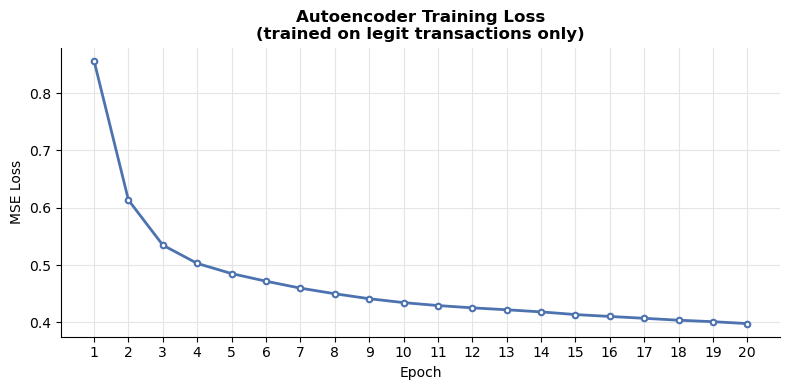

In [5]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(range(1, EPOCHS + 1), train_losses, color="#4C72B0",
        linewidth=2, marker="o", markersize=4,
        markerfacecolor="white", markeredgewidth=1.5)
ax.set_xlabel("Epoch")
ax.set_ylabel("MSE Loss")
ax.set_title("Autoencoder Training Loss\n"
             "(trained on legit transactions only)", fontweight="bold")
ax.set_xticks(range(1, EPOCHS + 1))
plt.tight_layout()
plt.savefig("phase3_autoencoder_training_loss.png", dpi=150, bbox_inches="tight")
plt.show()

### RECONSTRUCTION ERROR DISTRIBUTION


  Legit median reconstruction error : 0.276361
  Fraud median reconstruction error : 7.996694
  Ratio                              : 28.9x higher for fraud


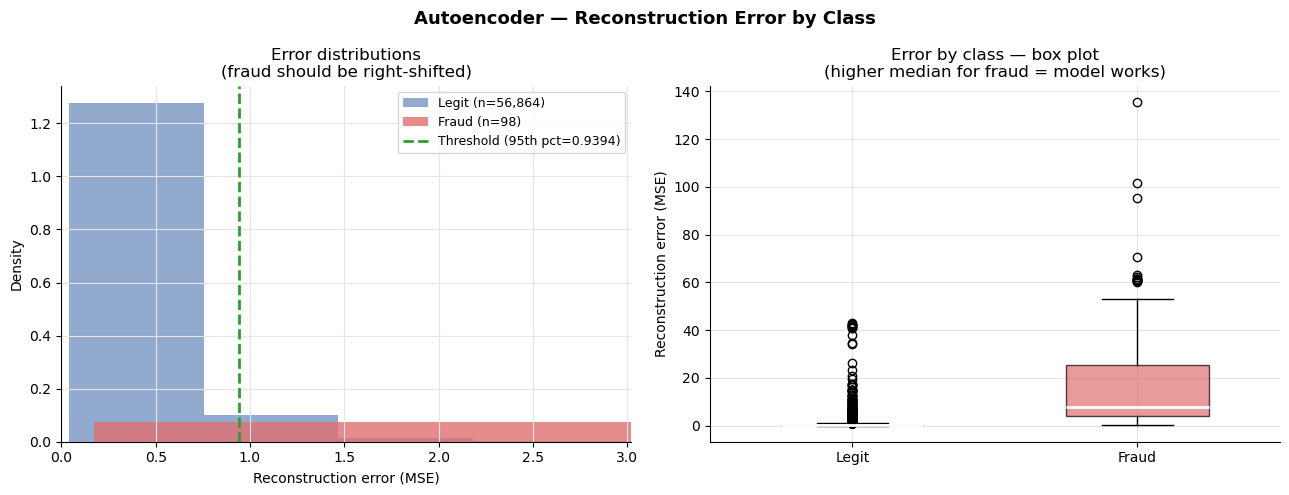

In [6]:
#    Key visual: fraud transactions should have HIGHER reconstruction error
#    because the model only learned to reconstruct normal transactions
# ════════════════════════════════════════════════════════════════════════════
 
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle("Autoencoder — Reconstruction Error by Class",
             fontweight="bold", fontsize=13)
 
# Panel 1: Histogram — overlapping distributions
ax = axes[0]
legit_errors = recon_errors[y_test == 0]
fraud_errors = recon_errors[y_test == 1]
 
ax.hist(legit_errors, bins=60, color="#4C72B0", alpha=0.6,
        density=True, label=f"Legit (n={len(legit_errors):,})",
        edgecolor="none")
ax.hist(fraud_errors, bins=30, color="#E07070", alpha=0.8,
        density=True, label=f"Fraud (n={len(fraud_errors)})",
        edgecolor="none")
ax.axvline(threshold_ae, color="#2ca02c", linestyle="--",
           linewidth=2, label=f"Threshold (95th pct={threshold_ae:.4f})")
ax.set_xlabel("Reconstruction error (MSE)")
ax.set_ylabel("Density")
ax.set_title("Error distributions\n(fraud should be right-shifted)")
ax.legend(fontsize=9)
# Clip x-axis to show separation clearly
ax.set_xlim(0, np.percentile(recon_errors, 99.5))
 
# Panel 2: Box plot comparison
ax2 = axes[1]
data_plot = [legit_errors, fraud_errors]
bp = ax2.boxplot(data_plot, labels=["Legit", "Fraud"],
                 patch_artist=True, widths=0.5,
                 medianprops={"color": "white", "linewidth": 2})
bp["boxes"][0].set_facecolor("#4C72B0")
bp["boxes"][0].set_alpha(0.7)
bp["boxes"][1].set_facecolor("#E07070")
bp["boxes"][1].set_alpha(0.7)
ax2.set_ylabel("Reconstruction error (MSE)")
ax2.set_title("Error by class — box plot\n(higher median for fraud = model works)")
 
# Print median errors
print(f"\n  Legit median reconstruction error : {np.median(legit_errors):.6f}")
print(f"  Fraud median reconstruction error : {np.median(fraud_errors):.6f}")
print(f"  Ratio                              : "
      f"{np.median(fraud_errors)/np.median(legit_errors):.1f}x higher for fraud")
 
plt.tight_layout()
plt.savefig("phase3_reconstruction_error.png", dpi=150, bbox_inches="tight")
plt.show()

### UNSUPERVISED MODEL COMPARISON


UNSUPERVISED MODEL COMPARISON
                  PR-AUC  Recall  Precision      F1    FN
Autoencoder       0.5067  0.8469     0.0291  0.0563  15.0
Isolation Forest  0.1572  0.3367     0.2245  0.2694  65.0


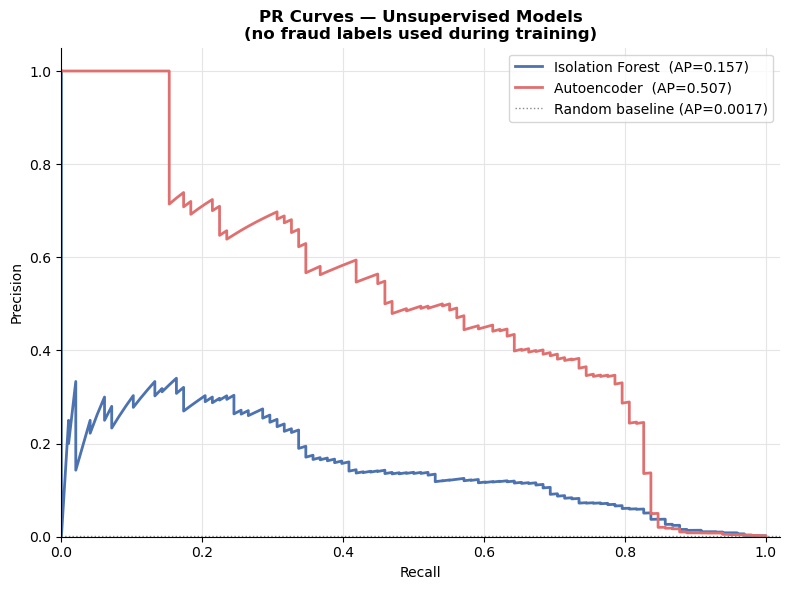

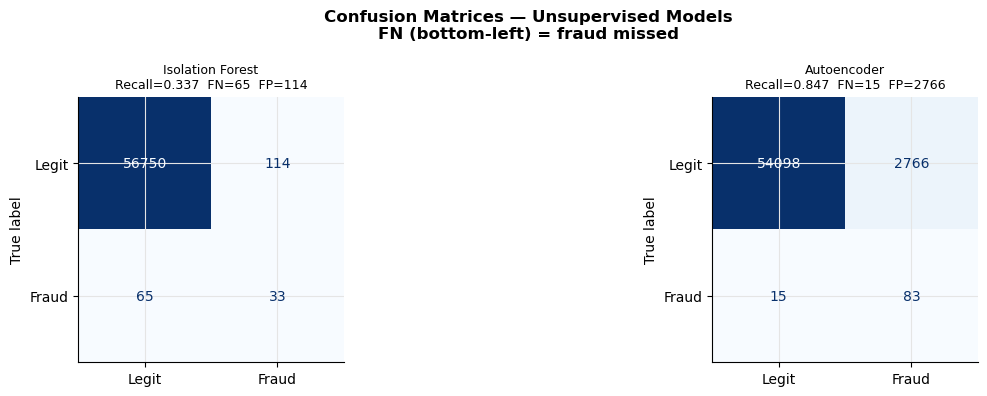

In [9]:
results_df = pd.DataFrame(results).T.sort_values("PR-AUC", ascending=False)
 
print("\n" + "=" * 60)
print("UNSUPERVISED MODEL COMPARISON")
print("=" * 60)
print(results_df.to_string())
 
# PR curves for all three
fig, ax = plt.subplots(figsize=(8, 6))
colors_map = {"Isolation Forest": "#4C72B0",
              "Autoencoder"     : "#E07070"}
 
for name, scores in anomaly_probs.items():
    prec_c, rec_c, _ = precision_recall_curve(y_test, scores)
    ap = average_precision_score(y_test, scores)
    ax.plot(rec_c, prec_c, color=colors_map[name],
            linewidth=2, label=f"{name}  (AP={ap:.3f})")
 
baseline = y_test.mean()
ax.axhline(baseline, color="#888", linestyle=":",
           linewidth=1, label=f"Random baseline (AP={baseline:.4f})")
ax.set_xlabel("Recall")
ax.set_ylabel("Precision")
ax.set_title("PR Curves — Unsupervised Models\n"
             "(no fraud labels used during training)", fontweight="bold")
ax.legend(fontsize=10)
ax.set_xlim(0, 1.02)
ax.set_ylim(0, 1.05)
plt.tight_layout()
plt.savefig("phase3_unsupervised_pr_curves.png", dpi=150, bbox_inches="tight")
plt.show()
 
# Confusion matrices — all three
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
fig.suptitle("Confusion Matrices — Unsupervised Models\n"
             "FN (bottom-left) = fraud missed", fontweight="bold")
 
preds_map = {
    "Isolation Forest": iso_pred,
    "Autoencoder"     : ae_pred,
}
for ax, (name, pred) in zip(axes, preds_map.items()):
    cm   = confusion_matrix(y_test, pred)
    disp = ConfusionMatrixDisplay(cm, display_labels=["Legit", "Fraud"])
    disp.plot(ax=ax, colorbar=False, cmap="Blues")
    fn = cm[1, 0]
    fp = cm[0, 1]
    rec = recall_score(y_test, pred, zero_division=0)
    ax.set_title(f"{name}\nRecall={rec:.3f}  FN={fn}  FP={fp}", fontsize=9)
    ax.set_xlabel("")
 
plt.tight_layout()
plt.savefig("phase3_confusion_matrices.png", dpi=150, bbox_inches="tight")
plt.show()

### SAVE PREDICTIONS FOR NEXT PHASE

In [11]:
unsup_df = pd.DataFrame({
    "y_true"   : y_test,
    "iso_score": anomaly_probs["Isolation Forest"],
    "ae_score" : anomaly_probs["Autoencoder"],
    "iso_pred" : iso_pred,
    "ae_pred"  : ae_pred,
})
unsup_df.to_csv("fraud_unsupervised_predictions.csv", index=False)
print("\nSaved: fraud_unsupervised_predictions.csv  ← used in Phase 4")


Saved: fraud_unsupervised_predictions.csv  ← used in Phase 4
